Sean Moriarty

In [65]:

import numpy as np
import pandas as pd
import matplotlib as ml
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

from sklearn.model_selection import train_test_split

# preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# training
from sklearn.model_selection import cross_validate

# tuning
from sklearn.model_selection import GridSearchCV

# validation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [66]:
# mount drive
drive.mount('/content/drive')

# importing intial data
train_path = '/content/drive/MyDrive/CSCI_460_Final_Project/to_uci/aps_failure_training_set.csv'
test_path = '/content/drive/MyDrive/CSCI_460_Final_Project/to_uci/aps_failure_test_set.csv'

# don't need the first 20 rows that's just info on data
df_aps_failure_training = pd.read_csv(train_path, skiprows=20, na_values='na')
df_aps_failure_test = pd.read_csv(test_path, skiprows=20, na_values='na')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


EDA start

In [67]:
# checking the inial shape of the data
print(df_aps_failure_training.shape)
print(df_aps_failure_test.shape)


(60000, 171)
(16000, 171)


In [68]:
# intial look at data
print(df_aps_failure_training.info())
print(df_aps_failure_training.head())
print(df_aps_failure_training.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), object(1)
memory usage: 78.3+ MB
None
  class  aa_000  ab_000        ac_000  ad_000  ae_000  af_000  ag_000  ag_001  \
0   neg   76698     NaN  2.130706e+09   280.0     0.0     0.0     0.0     0.0   
1   neg   33058     NaN  0.000000e+00     NaN     0.0     0.0     0.0     0.0   
2   neg   41040     NaN  2.280000e+02   100.0     0.0     0.0     0.0     0.0   
3   neg      12     0.0  7.000000e+01    66.0     0.0    10.0     0.0     0.0   
4   neg   60874     NaN  1.368000e+03   458.0     0.0     0.0     0.0     0.0   

   ag_002  ...     ee_002    ee_003    ee_004    ee_005    ee_006    ee_007  \
0     0.0  ...  1240520.0  493384.0  721044.0  469792.0  339156.0  157956.0   
1     0.0  ...   421400.0  178064.0  293306.0  245416.0  133654.0   81140.0   
2     0.0  ...   277378.0  159812.0  423992.0  409564.0  320746.0  158022.0   
3     0.0  ..

Data balance

In [69]:
# intial look at target class balance
print(df_aps_failure_training["class"].value_counts(normalize=True) * 100)
df_aps_failure_training['class'].value_counts()


class
neg    98.333333
pos     1.666667
Name: proportion, dtype: float64


,count
class,
neg,59000
pos,1000


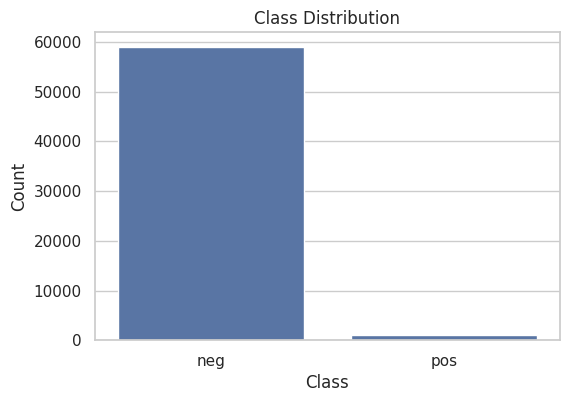

In [70]:
# plot of target data balance
sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
sns.countplot(data=df_aps_failure_training, x="class")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


Missing data

In [72]:
# intial look at missing data, total null
print(f"Total missing: {df_aps_failure_training.isnull().sum().sum()}")
missing_percent_data = df_aps_failure_training.isnull().mean() * 100
missing_percent_data.sort_values(ascending=False).head(15)


Total missing: 850015


,0
br_000,82.106667
bq_000,81.203333
bp_000,79.566667
bo_000,77.221667
ab_000,77.215000
cr_000,77.215000
bn_000,73.348333
bm_000,65.915000
bl_000,45.461667
bk_000,38.390000


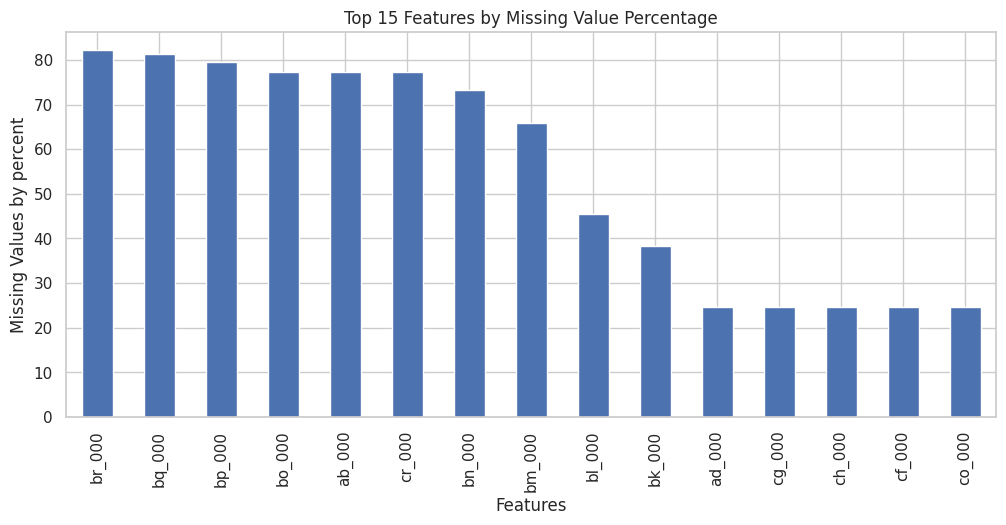

In [ ]:
plt.figure(figsize=(12,5))
missing_percent_data.sort_values(ascending=False).head(15).plot(kind="bar")
plt.title("Top 15 Features by Missing Value Percentage")
plt.xlabel("Features")
plt.ylabel("Missing Values by percent")
plt.show()

Data Correlation

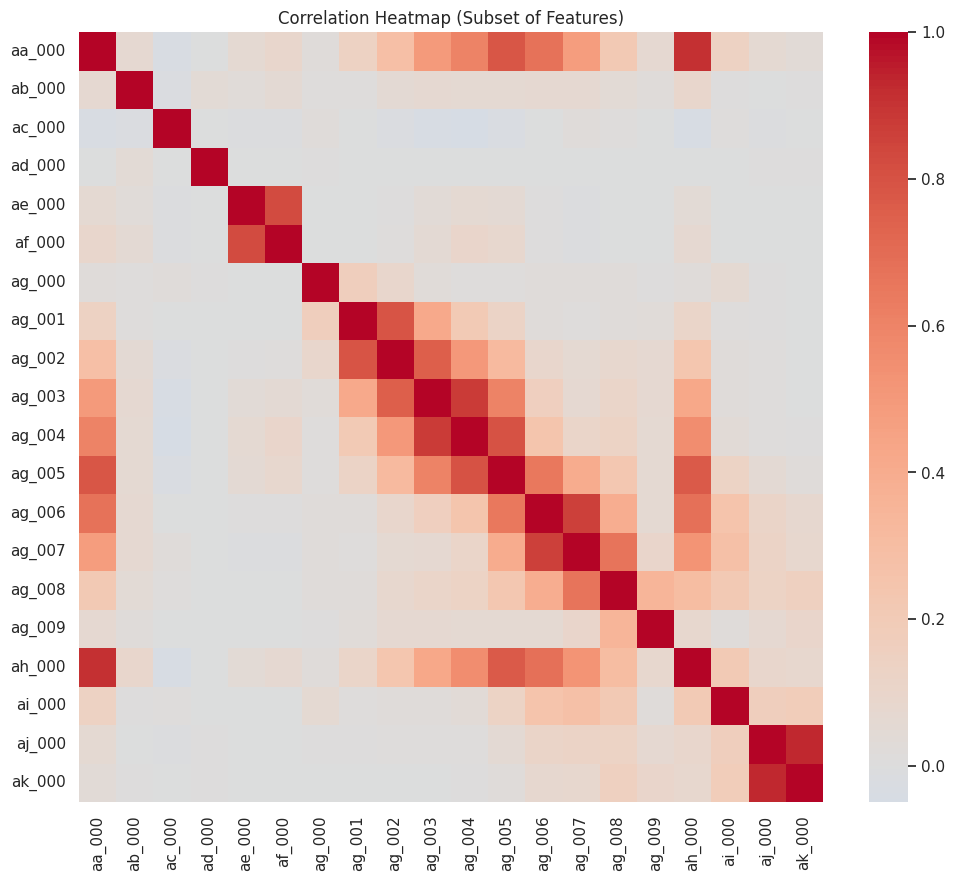

In [ ]:

# Take the top 20 colums
subset_cols = df_aps_failure_training.drop(columns=["class"]).columns[:20]
plt.figure(figsize=(12,10)
)
# plot their correlation
sns.heatmap(df_aps_failure_training[subset_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Subset of Features)")
plt.show()

EDA end

Preprocessing start

Drop features with high missing data

In [ ]:
# pereserve original data for now
df = df_aps_failure_training.copy()

# drop duplicates
df.drop_duplicates(keep='first', inplace=True)

# one hot encode target, only had one feature to encode
df["class"] = df["class"].map({"neg": 0, "pos": 1})

Split data

In [ ]:
# split
X = df.drop(columns=["class"])
y = df["class"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

Deal with missing data

In [ ]:
# get the columns with missing data over 70%
high_missing_cols = missing_percent_data[missing_percent_data > 70].index

# drop the colmumns
X_train = X_train.drop(columns=high_missing_cols)
X_test = X_test.drop(columns=high_missing_cols)


In [ ]:
# check shape
print(X_train.shape)
print(X_test.shape)

(48000, 163)
(12000, 163)


Impute missing data

In [ ]:
# Impute train and test
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

Scale the data

In [ ]:
# Scale train an test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [ ]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(48000, 163)
(12000, 163)


Reducs the data's dimentionality

In [46]:
# experimenting with pca values
pca_one = PCA(n_components=0.99)
X_train_pca_one = pca_one.fit_transform(X_train_scaled)
X_test_pca_one = pca_one.fit_transform(X_test_scaled)

In [47]:
# experimenting with pca values
pca_two = PCA(n_components=0.95)
X_train_pca_two = pca_two.fit_transform(X_train_scaled)
X_test_pca_two = pca_one.fit_transform(X_test_scaled)

Shape after preprocessing

In [55]:
print(X_train_pca_one.shape)
print(X_train_pca_two.shape)

(48000, 109)
(48000, 78)


Preprocessing end

Traing start

Models to be evaluated:
Logistic Regression,
K-Nearest Neighbors,
Support Vector Machine.
Decision Tree,
Random Forest,
SGD Classifier

In [ ]:
# Models to run cross validation on
X_train_sets = {"Scaled" : X_train_scaled,
                "PCA 99%" : X_train_pca_one,
                "PCA 95%" : X_train_pca_two }

# store for set results
set_results = []

# loop over sets
for set_name, X_train_set in X_train_sets.items():

  # make new models to train for every data set
  models = {
      "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
      "KNN": KNeighborsClassifier(),
      "SVM": SVC(class_weight="balanced"),
      "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
      "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
      "SGD Classifier": SGDClassifier(loss="log_loss", class_weight="balanced", random_state=42)
  }

  # track evaluation
  scoring = ["accuracy", "precision", "recall", "f1"]
  model_results = []

  # loop over models and cross validate
  for name, model in models.items():
      scores = cross_validate(
          model,
          X_train_set,
          y_train,
          cv=5,
          scoring=scoring,
          n_jobs=-1
      )

      # record model result
      model_results.append({
          "Model": name,
          "Accuracy": scores["test_accuracy"].mean(),
          "Precision": scores["test_precision"].mean(),
          "Recall": scores["test_recall"].mean(),
          "F1": scores["test_f1"].mean()
      })

  model_results_df = pd.DataFrame(model_results)
  set_results.append((set_name, model_results_df))

for set_name, set_result in set_results:
  print(f"Set: {set_name}\n {set_result}")


Set: Scaled
                  Model  Accuracy  Precision   Recall        F1
0  Logistic Regression  0.975833   0.400352  0.89250  0.552432
1                  KNN  0.989583   0.810996  0.49000  0.610706
2                  SVM  0.986563   0.565589  0.84375  0.676816
3        Decision Tree  0.986521   0.604273  0.55375  0.577726
4        Random Forest  0.991146   0.886945  0.53875  0.669393
5       SGD Classifier  0.951854   0.263623  0.93250  0.406390
Set: PCA 99%
                  Model  Accuracy  Precision  Recall        F1
0  Logistic Regression  0.975917   0.400897  0.8975  0.554180
1                  KNN  0.989646   0.814063  0.4925  0.613263
2                  SVM  0.985813   0.548956  0.8475  0.665895
3        Decision Tree  0.985229   0.568288  0.4925  0.527013
4        Random Forest  0.987958   0.951738  0.2925  0.446319
5       SGD Classifier  0.950062   0.242580  0.9250  0.383634
Set: PCA 95%
                  Model  Accuracy  Precision   Recall        F1
0  Logistic Regressio

In [63]:
all_results_df = pd.concat(
    [df.assign(Set=set_name) for set_name, df in set_results],
    ignore_index=True
)

all_results_df.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Precision,Recall,F1,Set
5,SGD Classifier,0.951854,0.263623,0.93250,0.406390,Scaled
11,SGD Classifier,0.950062,0.242580,0.92500,0.383634,PCA 99%
17,SGD Classifier,0.936604,0.210993,0.92500,0.339587,PCA 95%
12,Logistic Regression,0.973812,0.379605,0.90000,0.533913,PCA 95%
6,Logistic Regression,0.975917,0.400897,0.89750,0.554180,PCA 99%
0,Logistic Regression,0.975833,0.400352,0.89250,0.552432,Scaled
14,SVM,0.983625,0.505933,0.84875,0.633523,PCA 95%
8,SVM,0.985813,0.548956,0.84750,0.665895,PCA 99%
2,SVM,0.986563,0.565589,0.84375,0.676816,Scaled
3,Decision Tree,0.986521,0.604273,0.55375,0.577726,Scaled


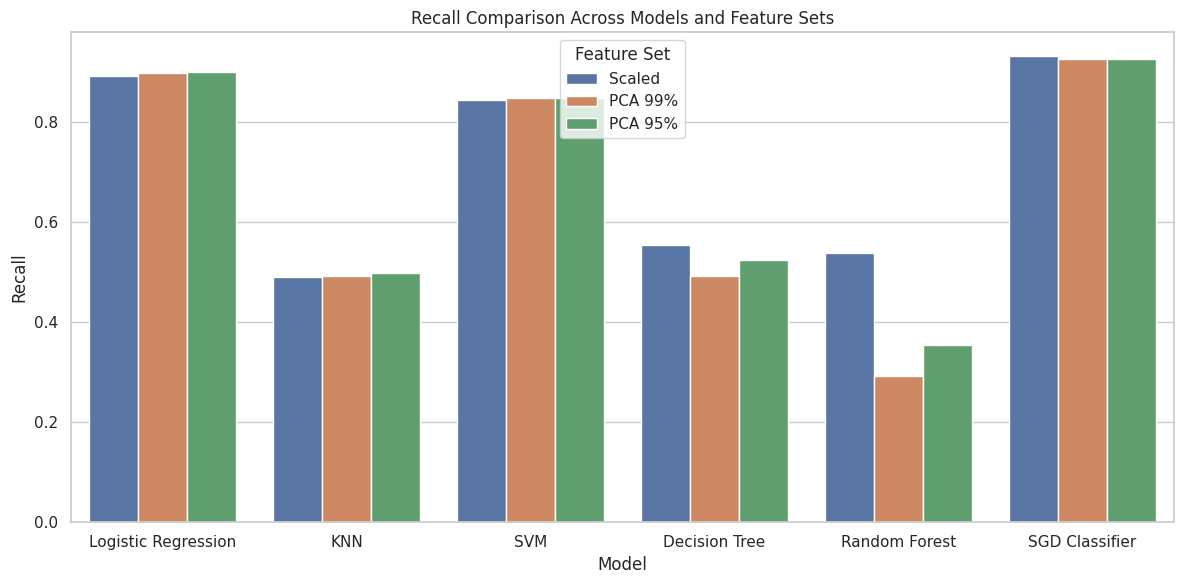

In [75]:
plt.figure(figsize=(12, 6))
sns.barplot(data=all_results_df, x="Model", y="Recall", hue="Set")
plt.title("Recall Comparison Across Models and Feature Sets")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.legend(title="Feature Set")
plt.tight_layout()
plt.show()

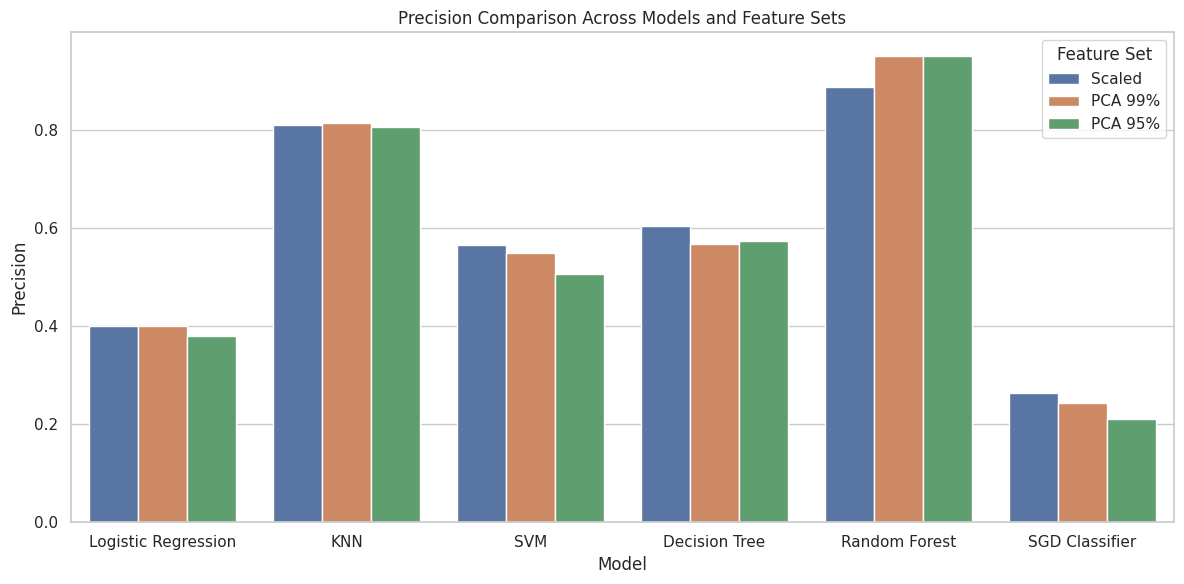

In [76]:
plt.figure(figsize=(12, 6))
sns.barplot(data=all_results_df, x="Model", y="Precision", hue="Set")
plt.title("Precision Comparison Across Models and Feature Sets")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.legend(title="Feature Set")
plt.tight_layout()
plt.show()

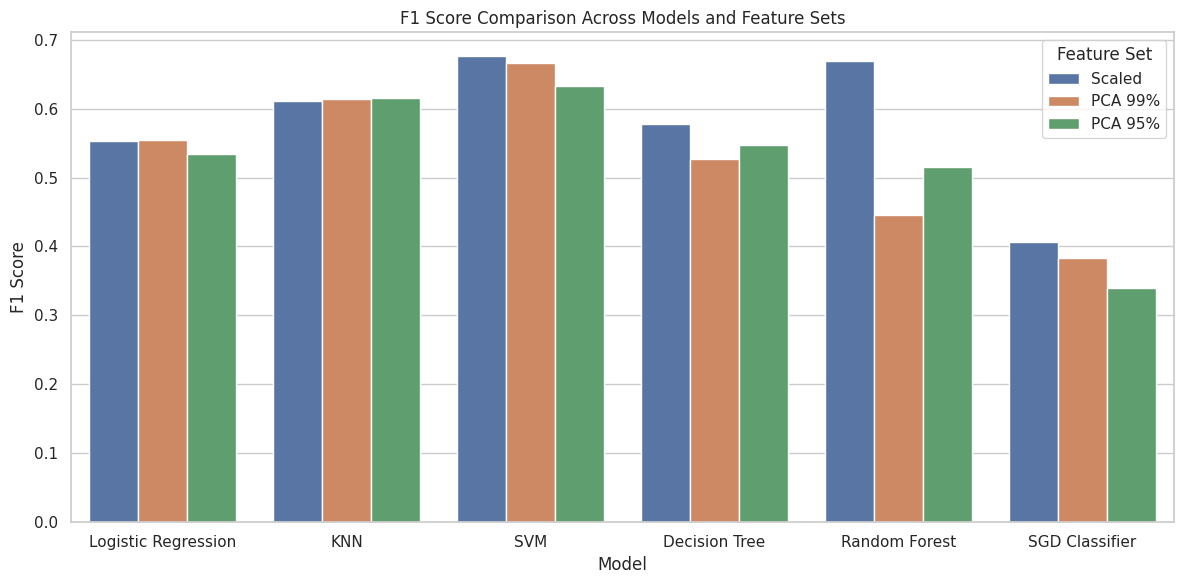

In [82]:
plt.figure(figsize=(12, 6))
sns.barplot(data=all_results_df, x="Model", y="F1", hue="Set")
plt.title("F1 Score Comparison Across Models and Feature Sets")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.legend(title="Feature Set")
plt.tight_layout()
plt.show()

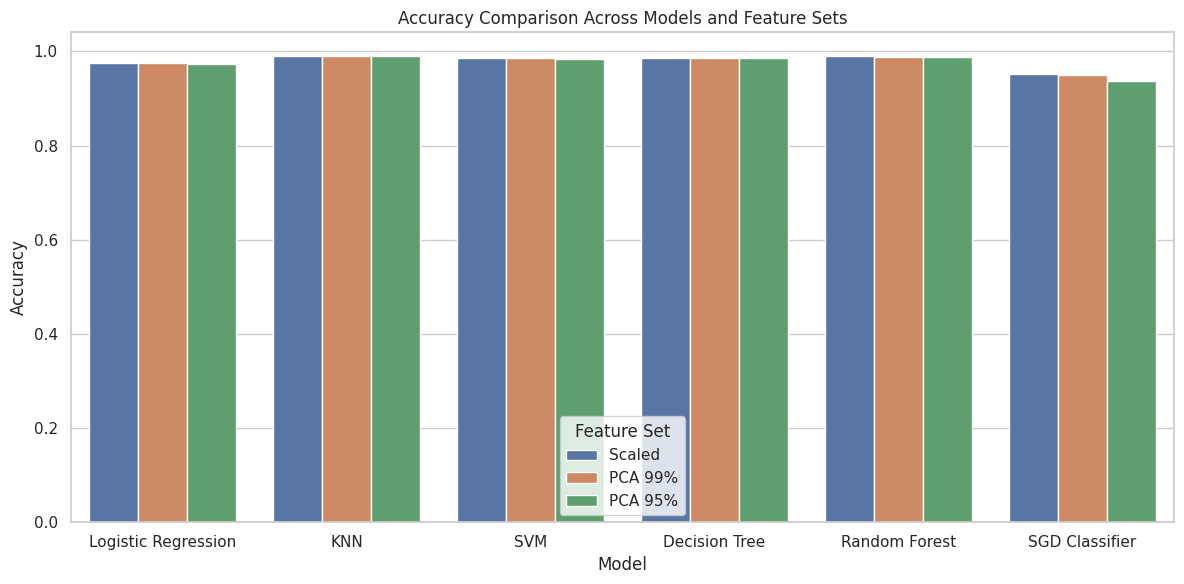

In [73]:
plt.figure(figsize=(12, 6))
sns.barplot(data=all_results_df, x="Model", y="Accuracy", hue="Set")
plt.title("Accuracy Comparison Across Models and Feature Sets")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.legend(title="Feature Set")
plt.tight_layout()
plt.show()

Initially all models were trained and evaluated using cross validation. Additionally, evaluating PCA at 99% and 95%, dimensionality reduction, showed a limited impact on the models' primary performance metric (recall). However, the initial cross validation did demonstrate that only Logistic Regression and SGD produced recall at or around 90% and given the goal of false negative minimization I will be tuning these two candidate models hyperparameters for the final model. Further, given the recall and F1 results of the cross validation comparison I trained the SGD Classifier and Logistic Regression model on the scaled data data set.

SGD Classifier

In [36]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(class_weight="balanced", random_state=42)

sgd_grid = {
    "loss": ["log_loss", "hinge"],
    "alpha": [0.0001, 0.001, 0.01],
    "penalty": ["l2", "l1"]
}

sgd_search = GridSearchCV(
    sgd,
    sgd_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

sgd_search.fit(X_train_scaled, y_train)

sgd_search.best_params_

{'alpha': 0.0001, 'loss': 'hinge', 'penalty': 'l2'}

Logistic Regression model

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

log_reg_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

log_reg_search = GridSearchCV(
    log_reg,
    log_reg_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

log_reg_search.fit(X_train_scaled, y_train)


log_reg_search.best_params_

{'C': 0.01, 'solver': 'liblinear'}

Training end

Conclusion

Best SGD internal

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     11800
           1       0.27      0.96      0.42       200

    accuracy                           0.96     12000
   macro avg       0.63      0.96      0.70     12000
weighted avg       0.99      0.96      0.97     12000



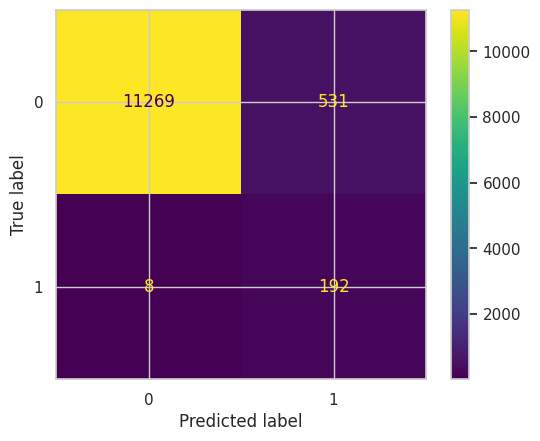

In [77]:
# get best model for sgd
best_SGD_model = sgd_search.best_estimator_

# train best model
best_SGD_model.fit(X_train_scaled, y_train)

# predict
y_pred = best_SGD_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

Best Logistic Regression internal

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     11800
           1       0.36      0.94      0.52       200

    accuracy                           0.97     12000
   macro avg       0.68      0.95      0.75     12000
weighted avg       0.99      0.97      0.98     12000



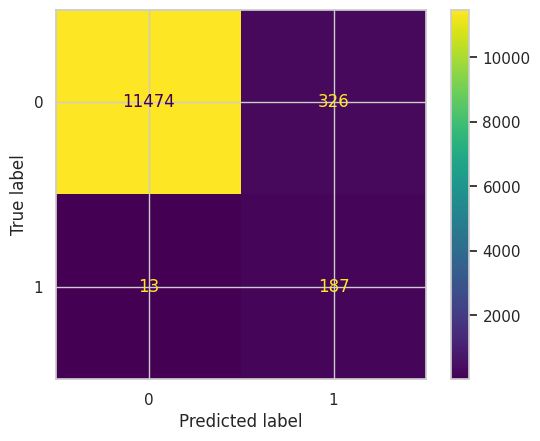

In [78]:
# get best model for log
best_log_model = log_reg_search.best_estimator_

# train best model
best_log_model.fit(X_train_scaled, y_train)

# predict
y_pred = best_log_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

Data set test data for final

In [79]:
# one hot encode
y_real_test = df_aps_failure_test["class"].map({"neg": 0, "pos": 1})

# drop same columns
X_real_test = df_aps_failure_test.drop(columns=["class"])
X_real_test = X_real_test.drop(columns=high_missing_cols)

# impute
X_real_test_imputed = imputer.transform(X_real_test)

# scale
X_real_test_scaled = scaler.transform(X_real_test_imputed)

SGD on real - Final

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     15625
           1       0.35      0.95      0.51       375

    accuracy                           0.96     16000
   macro avg       0.67      0.95      0.74     16000
weighted avg       0.98      0.96      0.97     16000



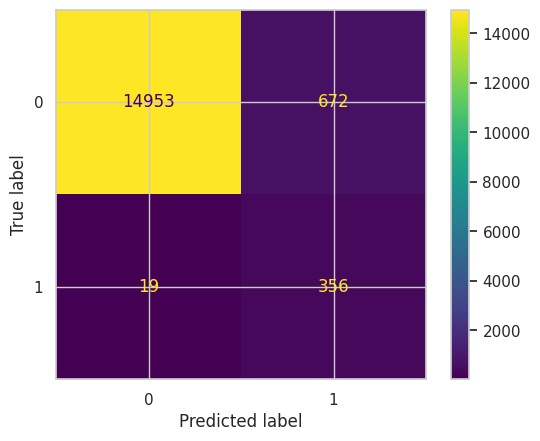

In [80]:
# predict
y_pred_real = best_SGD_model.predict(X_real_test_scaled)

print(classification_report(y_real_test, y_pred_real))
ConfusionMatrixDisplay.from_predictions(y_real_test, y_pred_real)

Log on real - Final

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     15625
           1       0.49      0.93      0.64       375

    accuracy                           0.98     16000
   macro avg       0.75      0.95      0.82     16000
weighted avg       0.99      0.98      0.98     16000



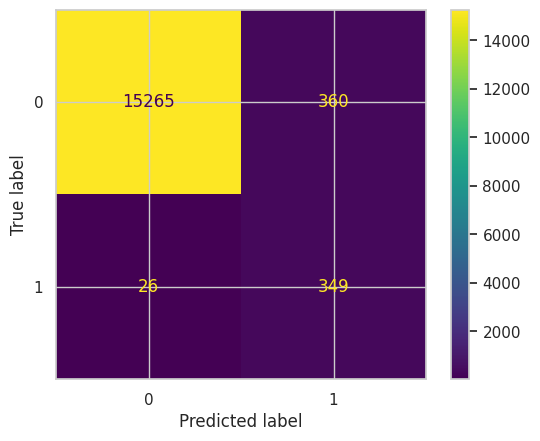

In [81]:
# predict
y_pred_real = best_log_model.predict(X_real_test_scaled)

print(classification_report(y_real_test, y_pred_real))
ConfusionMatrixDisplay.from_predictions(y_real_test, y_pred_real)

I've selected the Logistic Regression model as the final model. While the SGDClassifier achieved slightly higher recall, it would produce a significantly higher number of false positives due its low precision. Logistic Regression provides a better balance between recall and precision and still maintains a high recall. Hence the better F1 score.